# Core

> A convenience PyTorch Dataset factory for the IEMOCAP emotional speech dataset.

In [ ]:
#| default_exp core

In [ ]:
#| export

import io
import json
import os
import sqlite3
import urllib.request
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import soundfile as sf
import pandas as pd
import torch
from IPython.display import display, Audio
from torch.utils.data import Dataset
from tqdm.auto import tqdm

In [ ]:
#| export


class AudioSplitsDataset(Dataset):

    SPECTROGRAM_MAX_FREQUENCY = 8_000  # Hz
    LABELS_EMOTIONS = [
        "frustrated",
        "angry",
        "sad",
        "disgust",
        "excited",
        "fear",
        "neutral",
        "surprise",
        "happy",
    ]

    def __init__(
        self,
        df_dataset_audio_splits: pd.DataFrame,
        db_path: Path,
        n_fft: int,
        hop_length: int,
        win_length: int,
        n_mels: int,
        split_threshold_seconds: float,
        sample_rate: int,
    ):
        self.df_dataset_audio_splits = df_dataset_audio_splits
        self.db_path = db_path
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.n_mels = n_mels
        self.split_threshold_seconds = split_threshold_seconds
        self.sample_rate = sample_rate
        self.conn = None

    def __len__(self):
        return len(self.df_dataset_audio_splits)

    def __getitem__(self, idx: int):
        dataset_row = self.df_dataset_audio_splits.iloc[idx]
        source_row_index = dataset_row["source_dataset_row_index"]

        audio_array, sr = self.get_item_audio_bytes(idx)

        # Calculate log mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=audio_array,
            sr=sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            n_mels=self.n_mels,
            fmax=self.SPECTROGRAM_MAX_FREQUENCY,
        )
        # Convert power scale → log scale (closer to human hearing)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        features = torch.tensor(log_mel_spec, dtype=torch.float32)

        row = self.df_dataset_audio_splits.iloc[idx]
        labels = self._build_labels_tensor(row)

        return features, labels

    def get_item_audio_bytes(self, idx: int) -> tuple[npt.NDArray, int]:
        dataset_row = self.df_dataset_audio_splits.iloc[idx]
        db_row = self._fetch_db_record(dataset_row["source_dataset_row_index"])

        audio_bytes = db_row["audio_bytes"]

        # Decode audio using soundfile
        audio_array, sr = sf.read(io.BytesIO(audio_bytes), dtype="float32")

        # Slice the audio
        start = int(dataset_row["start_sample_offset"])
        end = int(dataset_row["end_sample_offset"])
        sliced_audio = audio_array[start:end]

        if dataset_row["should_add_padding"]:
            max_length = int(self.split_threshold_seconds * self.sample_rate)
            if len(sliced_audio) < max_length:
                sliced_audio = np.pad(sliced_audio, (0, max_length - len(sliced_audio)))

        return sliced_audio, sr

    def play_item_audio(self, idx: int):
        audio_array, sr = self.get_item_audio_bytes(idx)
        display(Audio(audio_array, rate=sr))

    def plot_melspectrogram(self, idx: int):
        dataset_row = self.df_dataset_audio_splits.iloc[idx]
        db_row = self._fetch_db_record(dataset_row["source_dataset_row_index"])

        features, _ = self[idx]
        spec = features.numpy().astype(np.float32)

        fig, ax = plt.subplots(figsize=(10, 4))

        total_split_parts = dataset_row.get("total_split_parts")
        split_part_idx = dataset_row.get("split_part_idx")
        if total_split_parts > 0:
            title = f"Split {int(split_part_idx) + 1} of {int(total_split_parts)}"
        else:
            title = "Single-Split"
        title += f'  |  {db_row["major_emotion"]}'

        img = ax.imshow(spec, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(title)
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Mel bands")
        plt.colorbar(img, ax=ax, format="%+2.0f dB")

        transcription = db_row["transcription"]
        if transcription:
            plt.suptitle(f'"{transcription.strip()}"', fontsize=11)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def get_labels_emotion_name(idx: int) -> str:
        return AudioSplitsDataset.LABELS_EMOTIONS[idx]

    def _get_conn(self):
        if self.conn is None:
            self.conn = sqlite3.connect(self.db_path)
            self.conn.row_factory = sqlite3.Row
        return self.conn

    def _fetch_db_record(self, source_row_index: int) -> dict:
        conn = self._get_conn()
        cursor = conn.cursor()
        cursor.execute(
            "SELECT audio_bytes, transcription, major_emotion FROM iemocap_dataset WHERE row_index = ?",
            (int(source_row_index),),
        )
        db_row = cursor.fetchone()

        if db_row is None:
            raise ValueError(f"Could not find row_index {source_row_index} in DB.")

        return db_row

    def _build_labels_tensor(self, row: pd.Series | dict) -> torch.Tensor:
        return torch.tensor(
            [row[f"reviewed_{emo}"] for emo in self.LABELS_EMOTIONS],
            dtype=torch.float32,
        )

In [ ]:
#| export

class DatasetsFactory:

    JSON_FILE_NAME = "dataset_audio_split_groups.json"
    IEMOCAP_DB_FILE_NAME = "iemocap_dataset_table.db"

    def __init__(
        self,
        url: str,
        override_cache_dir: Path | None = None,
        refresh_json_file: bool = True,
        refresh_sqlite_file: bool = False,
    ):
        self.url = url.rstrip("/")
        self.cache_dir = (
            Path(override_cache_dir)
            if override_cache_dir
            else Path.home() / ".cache" / "upc-aidl-iemocap-datasets"
        )
        self.cache_dir.mkdir(parents=True, exist_ok=True)

        self.json_path = self.cache_dir / self.JSON_FILE_NAME
        self.db_path = self.cache_dir / self.IEMOCAP_DB_FILE_NAME

        # Mapped JSON_FILE_NAME manifest *adding* local parquet file path.
        # {dataset_audio_split_groups.id: dataset_audio_split_group | _parquet_path, ...}
        self.dataset_audio_split_groups = {}

        # Initial download of manifest and DB
        self._sync(refresh_json_file, refresh_sqlite_file)

    def _sync(self, refresh_json_file: bool = True, refresh_sqlite_file: bool = False):
        if refresh_json_file or not self.json_path.exists():
            print(f"Downloading dataset manifest...")
            self._download_file(
                f"{self.url}/{self.JSON_FILE_NAME}", self.json_path, "Manifest"
            )

        # The SQLite database shouldn't change from the initial version, so no need for a regular refresh.
        if refresh_sqlite_file or not self.db_path.exists():
            print("Downloading SQLite database...")
            self._download_file(
                f"{self.url}/{self.IEMOCAP_DB_FILE_NAME}", self.db_path, "SQLite DB"
            )

        with open(self.json_path, "r") as f:
            json_manifest = json.load(f)
            self.mapped_manifest = {group["id"]: group for group in json_manifest}

        for group_id, group in self.mapped_manifest.items():
            parquet_url = group["last_export_filename"]
            parquet_filename = self._extract_dataset_audio_splits_file_name(parquet_url)
            parquet_path = self.cache_dir / parquet_filename

            if not parquet_path.exists():
                print(f"Downloading {parquet_filename}...")
                self._download_file(parquet_url, parquet_path, parquet_filename)

            # Map the path the local parquet file
            self.mapped_manifest[group_id]["_parquet_path"] = parquet_path

    def _extract_dataset_audio_splits_file_name(self, last_export_filename_url: str) -> str:
        return last_export_filename_url.split("/")[-1]

    def _refresh_json_manifest_and_dataset_audio_splits(self):
        if self.json_path.exists():
            self.json_path.unlink()
        self._sync(refresh_json_file=True)

    def _download_file(self, url: str, filepath: Path, desc=None):
        response = urllib.request.urlopen(url)
        total_size = int(response.headers.get("content-length", 0))
        block_size = 1024 * 8

        with tqdm(total=total_size, unit="B", unit_scale=True, desc=desc) as pbar:
            with open(filepath, "wb") as f:
                while True:
                    buffer = response.read(block_size)
                    if not buffer:
                        break
                    f.write(buffer)
                    pbar.update(len(buffer))

    def get_dataset_audio_split_groups(self, should_refresh_local_cache: bool = False) -> pd.DataFrame:
        if should_refresh_local_cache:
            self._refresh_json_manifest_and_dataset_audio_splits()

        return pd.DataFrame(list(self.mapped_manifest.values()))

    def build_dataset(
        self,
        id: int,
        n_fft: int,
        hop_length: int,
        win_length: int,
        n_mels: int,
        should_refresh_local_cache: bool = True,
    ):
        if should_refresh_local_cache:
            self._refresh_json_manifest_and_dataset_audio_splits()

        # Find the group
        group = self.mapped_manifest[id]

        parquet_url = group["last_export_filename"]
        parquet_filename = self._extract_dataset_audio_splits_file_name(parquet_url)
        parquet_path = self.cache_dir / parquet_filename

        df = pd.read_parquet(parquet_path)
        df = df[df["should_exclude"] == False].copy()
        df = df.reset_index(drop=True)

        return AudioSplitsDataset(
            df_dataset_audio_splits=df,
            db_path=self.db_path,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
            split_threshold_seconds=group["split_threshold_seconds"],
            sample_rate=group["sample_rate"],
        )

## Tests

We can test the datasets factory by stubbing out the remote R2 downloads and providing a temporary SQLite database and parquet files.

In [ ]:
from unittest.mock import patch
from urllib.error import HTTPError

from nbdev_upc_aidl_iemocap_datasets.test_utils import create_test_fixtures

In [ ]:
tmpdir, tests_path = create_test_fixtures()

Test the DatasetsFactory initalization

In [ ]:
# Test connection error
try:
    factory = DatasetsFactory(
        url="http://example.com",
        override_cache_dir=tests_path,
    )
    raise AssertionError("The download function should throw an error when datasets from example.com")
except HTTPError:
    print("✅ The download function is not patched.")


✅ The download function is not patched.


In [ ]:
# Test cache read
temp_json_file_path = tests_path / DatasetsFactory.JSON_FILE_NAME
assert temp_json_file_path.exists()
factory = DatasetsFactory(
    url="http://example.com",
    override_cache_dir=tests_path,
    refresh_json_file=False,
    refresh_sqlite_file=False,
)
df_manifest = factory.get_dataset_audio_split_groups()
assert len(df_manifest) == 1
print("✅ Factory manifest listing works from test cache.")

✅ Factory manifest listing works from test cache.


In [ ]:
with patch.object(DatasetsFactory, "_download_file") as mock_download_file:
    # Initialize factory pointing to our temp cache directory
    test_url = "http://example.com/"

    factory = DatasetsFactory(
        url=test_url,
        override_cache_dir=tests_path,
    )
    mock_download_file.assert_called_once_with(
        test_url + DatasetsFactory.JSON_FILE_NAME,
        temp_json_file_path,
        "Manifest",
    )

    df_manifest = factory.get_dataset_audio_split_groups()
    assert mock_download_file.call_count == 1
    assert len(df_manifest) == 1
    print("✅ Factory manifest listing works!")

df_manifest

✅ Factory manifest listing works!


,id,split_threshold_seconds,previous_overlap_seconds,sample_rate,last_export_filename,last_export_at,_parquet_path
0,1,4.8,0.2,16000,http://example.com/dataset_audio_splits/group_...,2026-05-16 22:01:23.000000,/var/folders/bn/87jpkfs15bl3l7j40cpcr6140000gn...


Test building a dataset from DatasetFactory

In [ ]:
ds = factory.build_dataset(
    id=1, n_fft=1024, hop_length=200, win_length=400, n_mels=80, should_refresh_local_cache=False
)
assert len(ds) == 3
print("✅ Dataset building works!")

✅ Dataset building works!


In [ ]:
# Test retrieving the first item
features, labels = ds[0]

# n_mels = 80, so features tensor should have 80 mel frequency bins
assert features.shape[0] == 80

# total time frames = split_threshold_seconds / (hop_length / sample_rate)
assert features.shape[1] == 385

# Check labels
assert labels.shape[0] == len(AudioSplitsDataset.LABELS_EMOTIONS)
assert torch.allclose(
    labels,
    torch.tensor(
        [0.635, 0.320, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006]
    ),
)
for i, emotion in enumerate(AudioSplitsDataset.LABELS_EMOTIONS):
    assert emotion == AudioSplitsDataset.get_labels_emotion_name(i)
print("✅ Feature extraction and label tensor generation works!")

✅ Feature extraction and label tensor generation works!


In [ ]:
ds.play_item_audio(0)

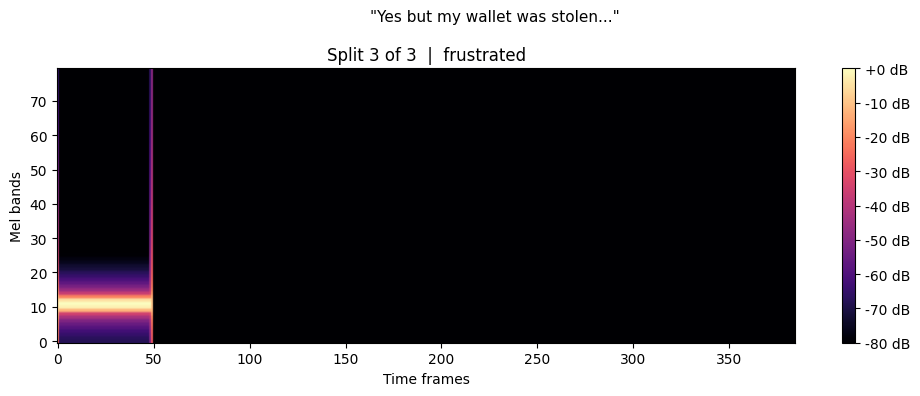

In [ ]:
ds.plot_melspectrogram(2)

In [ ]:
# Tests temporary directory clean-up
tmpdir.cleanup()